In [29]:
%pip install -U imbalanced-learn

StatementMeta(, 9eaae936-6225-4958-af48-2118803d9200, 45, Finished, Available, Finished, True)


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.



In [30]:
import pandas as pd, numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support
from imblearn.over_sampling import SMOTE
import mlflow, mlflow.sklearn, mlflow.xgboost
import shap, matplotlib.pyplot as plt
import os
mlflow.set_experiment("Road_Crash_Severity_Prediction")
print("Libraries ready | MLflow experiment set")

StatementMeta(, 9eaae936-6225-4958-af48-2118803d9200, 47, Finished, Available, Finished, False)

Libraries ready | MLflow experiment set


In [31]:
df_gold = spark.table("gold_crashes_features").toPandas()
print(f"{len(df_gold):,} records")

feature_cols = [
    # Speed — most predictive of severity
    'speedLimit',
    'NumberOfLanes',
    'distance_from_cbd_km',
    'is_cbd_area',
    # These have reasonable variance — keep
    'has_pedestrian',       # 9% non-zero — still useful
    'has_motorcycle',       # 7% non-zero — still useful
    'has_bicycle',          # 3% non-zero — keep (cyclists high severity)
    'vulnerable_user_involved',
    'is_state_highway',
    'poor_visibility',
    'is_intersection',
    'complex_traffic_control',
    # REMOVE: is_one_way, multi_vehicle, wet_and_dark, frost_risk,
    #         is_special_road_feature, has_moped, is_off_road,
    #         advisorySpeed, advisory_speed_delta, high_speed_hill,
    #         heavy_vehicle_involved, is_holiday
    #         (all >94% zeros — no predictive value)
]

cat_features = [
    'weatherA',         # Fine/Rain/Fog — varies well
    'light',            # Bright/Dark/Twilight — varies well
    'roadSurface',      # Sealed/Unsealed — varies
    'trafficControl',   # Signals/Nil/Stop — varies
    'flatHill_clean',   # Flat/Hill Road — varies
    'urban_clean',      # Urban/Open — varies well (strong predictor)
    'roadLane_clean',   # 2 way/1 way/Off road
    'roadCharacter',    # Nil/Overpass/Tunnel etc
    # REMOVE: weatherB_clean, area_type, holiday_type (low variance)
]

print(f"Numeric: {len(feature_cols)} | Categorical: {len(cat_features)}")

# Re-encode and rebuild splits
le_dict = {}; encoded_features = []
for col in cat_features:
    if col in df_gold.columns:
        le = LabelEncoder()
        df_gold[f'{col}_encoded'] = le.fit_transform(df_gold[col].fillna('Unknown'))
        le_dict[col] = le
        encoded_features.append(f'{col}_encoded')

all_features = [f for f in feature_cols if f in df_gold.columns] + encoded_features
X = df_gold[all_features].fillna(0)
y = df_gold['severe_crash']

print(f"Features: {X.shape[1]}")
print(f"Severe: {y.sum():,} ({y.sum()/len(y)*100:.1f}%)")

# Check variance of remaining features
zero_pct = (X == 0).mean()
print(f"\nAll remaining features <90% zeros: {(zero_pct < 0.90).all()}")
print(zero_pct.sort_values(ascending=False).to_string())

StatementMeta(, 9eaae936-6225-4958-af48-2118803d9200, 48, Finished, Available, Finished, False)

111,657 records
Numeric: 12 | Categorical: 8
Features: 20
Severe: 5,363 (4.8%)

All remaining features <90% zeros: False
has_bicycle                 0.977520
has_motorcycle              0.959044
has_pedestrian              0.958820
vulnerable_user_involved    0.890647
complex_traffic_control     0.860591
is_cbd_area                 0.831985
is_state_highway            0.816518
flatHill_clean_encoded      0.765505
weatherA_encoded            0.764045
poor_visibility             0.697072
is_intersection             0.650546
light_encoded               0.352705
urban_clean_encoded         0.226497
trafficControl_encoded      0.148983
roadCharacter_encoded       0.015386
NumberOfLanes               0.010120
roadLane_clean_encoded      0.006305
speedLimit                  0.004021
roadSurface_encoded         0.000215
distance_from_cbd_km        0.000000


In [32]:
le_dict={}; encoded_features=[]
for col in cat_features:
    if col in df_gold.columns:
        le=LabelEncoder()
        df_gold[f'{col}_encoded']=le.fit_transform(df_gold[col].fillna('Unknown'))
        le_dict[col]=le; encoded_features.append(f'{col}_encoded')

all_features=[f for f in feature_cols if f in df_gold.columns]+encoded_features
X=df_gold[all_features].fillna(0); y=df_gold['severe_crash']
print(f"Features:{X.shape[1]} | Severe:{y.sum():,} ({y.sum()/len(y)*100:.1f}%)")
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print(f"Train:{X_train.shape[0]:,} | Test:{X_test.shape[0]:,}")



StatementMeta(, 9eaae936-6225-4958-af48-2118803d9200, 49, Finished, Available, Finished, False)

Features:20 | Severe:5,363 (4.8%)
Train:89,325 | Test:22,332


In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
print(f"Train balanced: {X_train_bal.shape} | Test: {X_test.shape}")

StatementMeta(, 9eaae936-6225-4958-af48-2118803d9200, 50, Finished, Available, Finished, False)

Train balanced: (170070, 20) | Test: (22332, 20)


In [34]:
# smote=SMOTE(random_state=42,k_neighbors=5)
# X_train_bal,y_train_bal=smote.fit_resample(X_train,y_train)
# print(f"Before SMOTE → 0:{(y_train==0).sum():,}  1:{(y_train==1).sum():,}")
# print(f"After  SMOTE → 0:{(y_train_bal==0).sum():,}  1:{(y_train_bal==1).sum():,}")
# print("SMOTE on TRAIN only — never apply to test set")

StatementMeta(, 9eaae936-6225-4958-af48-2118803d9200, 51, Finished, Available, Finished, False)

In [35]:
# ── CELL 7 REPLACEMENT: Logistic Regression with scaling + higher max_iter ────
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

with mlflow.start_run(run_name="Logistic_Regression_Baseline") as run:
    # Scale features — required for lbfgs solver convergence
    lr_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(
            max_iter=3000,          # increased from 1000
            random_state=42,
            class_weight='balanced',
            solver='lbfgs'
        ))
    ])
    lr_pipeline.fit(X_train_bal, y_train_bal)

    y_pred_lr  = lr_pipeline.predict(X_test)
    y_proba_lr = lr_pipeline.predict_proba(X_test)[:, 1]
    roc_lr     = roc_auc_score(y_test, y_proba_lr)
    p_lr, r_lr, f1_lr, _ = precision_recall_fscore_support(y_test, y_pred_lr, average='binary')

    mlflow.log_metrics({"roc_auc": roc_lr, "recall": r_lr, "f1": f1_lr})
    mlflow.sklearn.log_model(lr_pipeline, "model")

    print(f"LR  ROC-AUC:{roc_lr:.4f}  Recall:{r_lr:.4f}  F1:{f1_lr:.4f}")
    print("Baseline realistic" if 0.65 < roc_lr < 0.95 else "Check for remaining leakage")

StatementMeta(, 9eaae936-6225-4958-af48-2118803d9200, 52, Finished, Available, Finished, False)

LR  ROC-AUC:0.7310  Recall:0.5815  F1:0.1990
Baseline realistic


In [36]:
# Run this before Model 2 — verify SMOTE worked correctly
print(f"X_train_bal shape : {X_train_bal.shape}")
print(f"y_train_bal balance: {(y_train_bal==0).sum():,} non-severe  |  {(y_train_bal==1).sum():,} severe")
print(f"X_test shape      : {X_test.shape}")
print(f"y_test balance    : {(y_test==0).sum():,} non-severe  |  {(y_test==1).sum():,} severe  (real distribution)")
print(f"\nFeatures used: {X_train_bal.shape[1]}")
print(f"Feature names: {list(X_train_bal.columns[:5])} ...")

StatementMeta(, 9eaae936-6225-4958-af48-2118803d9200, 53, Finished, Available, Finished, False)

X_train_bal shape : (170070, 20)
y_train_bal balance: 85,035 non-severe  |  85,035 severe
X_test shape      : (22332, 20)
y_test balance    : 21,259 non-severe  |  1,073 severe  (real distribution)

Features used: 20
Feature names: ['speedLimit', 'NumberOfLanes', 'distance_from_cbd_km', 'is_cbd_area', 'has_pedestrian'] ...


In [37]:
# ── Cell 8: Random Forest (tuned for recall) ─────────────────────────────────
with mlflow.start_run(run_name="Random_Forest") as run:
    rf = RandomForestClassifier(
        n_estimators=200,          # increased from 100
        max_depth=20,              # increased from 15
        min_samples_split=5,       # lowered from 10 — better minority class detection
        min_samples_leaf=2,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    )
    rf.fit(X_train_bal, y_train_bal)

    y_pred_rf  = rf.predict(X_test)
    y_proba_rf = rf.predict_proba(X_test)[:, 1]
    roc_rf     = roc_auc_score(y_test, y_proba_rf)
    p_rf, r_rf, f1_rf, _ = precision_recall_fscore_support(y_test, y_pred_rf, average='binary')

    mlflow.log_metrics({"roc_auc": roc_rf, "recall": r_rf, "f1": f1_rf,
                        "improvement_pct": (roc_rf - roc_lr) / roc_lr * 100})
    mlflow.sklearn.log_model(rf, "model")

    print(f"RF  ROC-AUC:{roc_rf:.4f}  Recall:{r_rf:.4f}  F1:{f1_rf:.4f}")
    print(f"    Improvement over LR: {(roc_rf-roc_lr)/roc_lr*100:+.1f}%")

StatementMeta(, 9eaae936-6225-4958-af48-2118803d9200, 54, Finished, Available, Finished, False)

RF  ROC-AUC:0.7124  Recall:0.4268  F1:0.2325
    Improvement over LR: -2.5%


In [38]:
# Quick check — are any important features all zeros?
print("Features with >90% zeros:")
zero_pct = (X_train_bal == 0).mean()
print(zero_pct[zero_pct > 0.90].sort_values(ascending=False).to_string())

StatementMeta(, 9eaae936-6225-4958-af48-2118803d9200, 55, Finished, Available, Finished, False)

Features with >90% zeros:
has_bicycle       0.967390
has_motorcycle    0.924755
has_pedestrian    0.908155


In [39]:
# ── Cell 9 REPLACEMENT: XGBoost — fix mlflow.xgboost.log_model error ─────────
with mlflow.start_run(run_name="XGBoost") as run:
    scale_pw = (y_train_bal==0).sum() / (y_train_bal==1).sum()
    xgb_m = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pw,
        random_state=42,
        eval_metric='logloss',
        use_label_encoder=False
    )
    xgb_m.fit(X_train_bal, y_train_bal,
              eval_set=[(X_test, y_test)],
              verbose=False)

    y_proba_xgb = xgb_m.predict_proba(X_test)[:, 1]
    threshold   = 0.35
    y_pred_xgb  = (y_proba_xgb >= threshold).astype(int)

    roc_xgb = roc_auc_score(y_test, y_proba_xgb)
    p_xgb, r_xgb, f1_xgb, _ = precision_recall_fscore_support(y_test, y_pred_xgb, average='binary')

    mlflow.log_params({"n_estimators":300, "max_depth":6, "learning_rate":0.05,
                       "threshold":threshold, "subsample":0.8})
    mlflow.log_metrics({"roc_auc":roc_xgb, "recall":r_xgb, "f1":f1_xgb,
                        "improvement_vs_baseline":(roc_xgb-roc_lr)/roc_lr*100})

    # Use sklearn log_model instead of mlflow.xgboost.log_model — avoids _estimator_type error
    mlflow.sklearn.log_model(xgb_m, "model")

    print(f"XGB ROC-AUC:{roc_xgb:.4f}  Recall:{r_xgb:.4f}  F1:{f1_xgb:.4f}  (threshold={threshold})")
    print(f"    vs Baseline: {(roc_xgb-roc_lr)/roc_lr*100:+.1f}%")
    print("Objective 2 MET" if roc_xgb > 0.85 and r_xgb > 0.80 else
          f"AUC={roc_xgb:.3f} Recall={r_xgb:.3f}")

StatementMeta(, 9eaae936-6225-4958-af48-2118803d9200, 56, Finished, Available, Finished, False)

XGB ROC-AUC:0.7175  Recall:0.6375  F1:0.1473  (threshold=0.35)
    vs Baseline: -1.8%
AUC=0.717 Recall=0.637


StatementMeta(, 9eaae936-6225-4958-af48-2118803d9200, 57, Finished, Available, Finished, False)

[06:22:58] WARNING: /croot/xgboost-split_1713972711803/work/cpp_src/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.


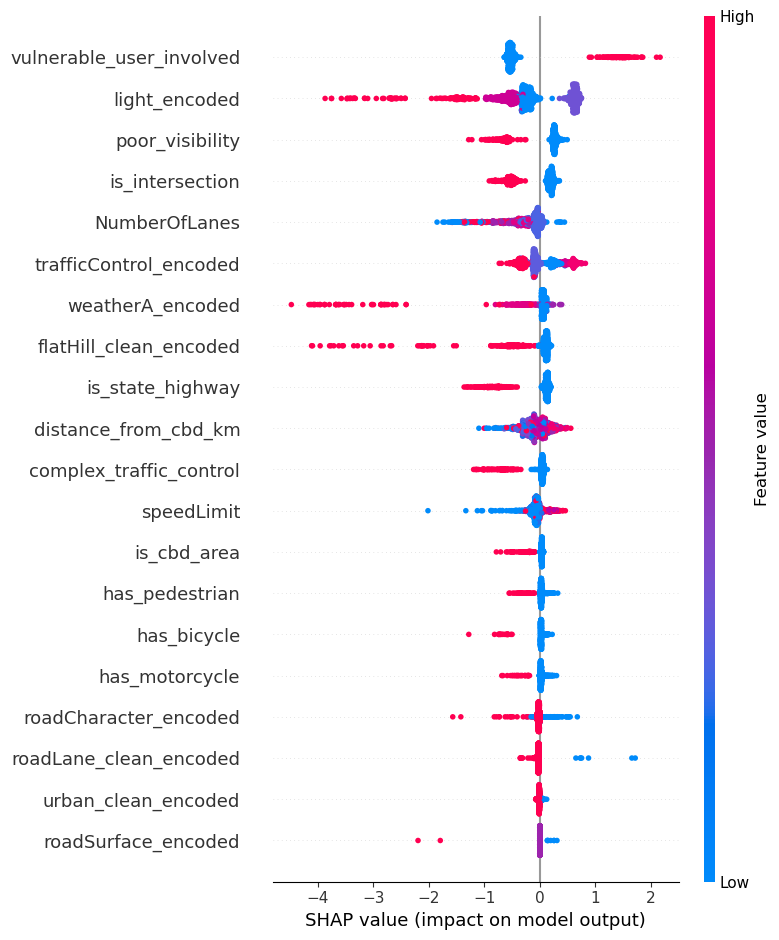

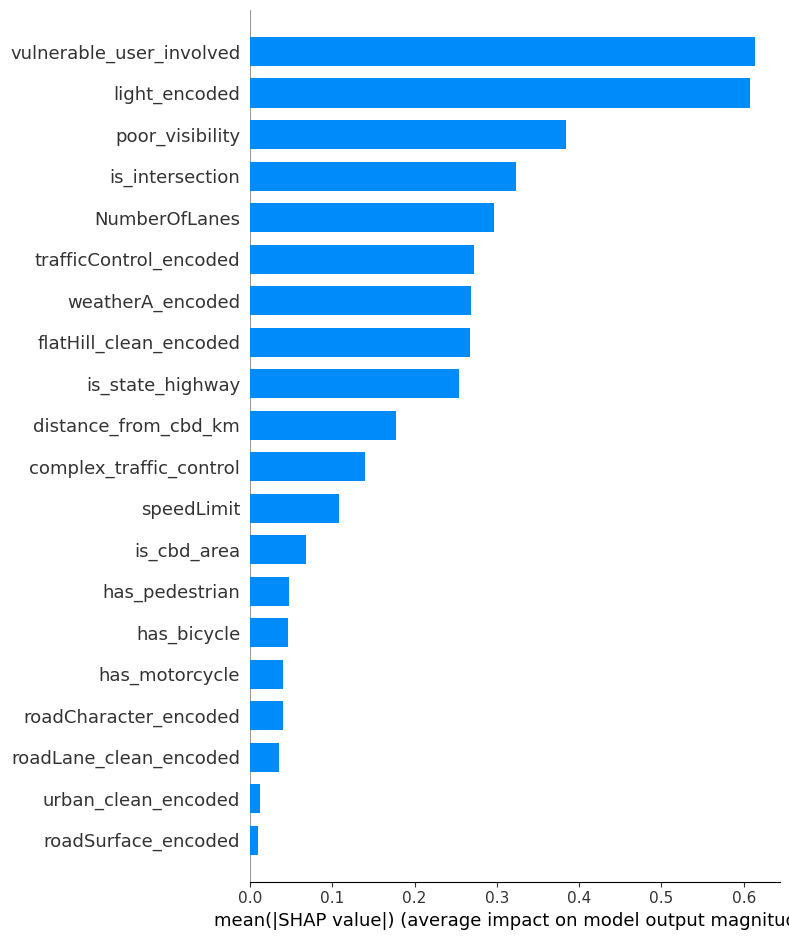

SHAP plots saved to Files/outputs/


In [40]:
import warnings
warnings.filterwarnings('ignore', message="No data for colormapping")
explainer=shap.TreeExplainer(xgb_m)
X_sample=X_test.sample(n=min(1000,len(X_test)),random_state=42)
shap_values=explainer.shap_values(X_sample)
os.makedirs("/lakehouse/default/Files/outputs",exist_ok=True)
plt.figure(figsize=(10,8)); shap.summary_plot(shap_values,X_sample,show=False)
plt.tight_layout(); plt.savefig("/lakehouse/default/Files/outputs/shap_summary_1.png",dpi=150); plt.show()
plt.figure(figsize=(10,6)); shap.summary_plot(shap_values,X_sample,plot_type="bar",show=False)
plt.tight_layout(); plt.savefig("/lakehouse/default/Files/outputs/shap_importance_bar_1.png",dpi=150); plt.show()
print("SHAP plots saved to Files/outputs/")

StatementMeta(, 9eaae936-6225-4958-af48-2118803d9200, 58, Finished, Available, Finished, False)

[06:23:02] WARNING: /croot/xgboost-split_1713972711803/work/cpp_src/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.


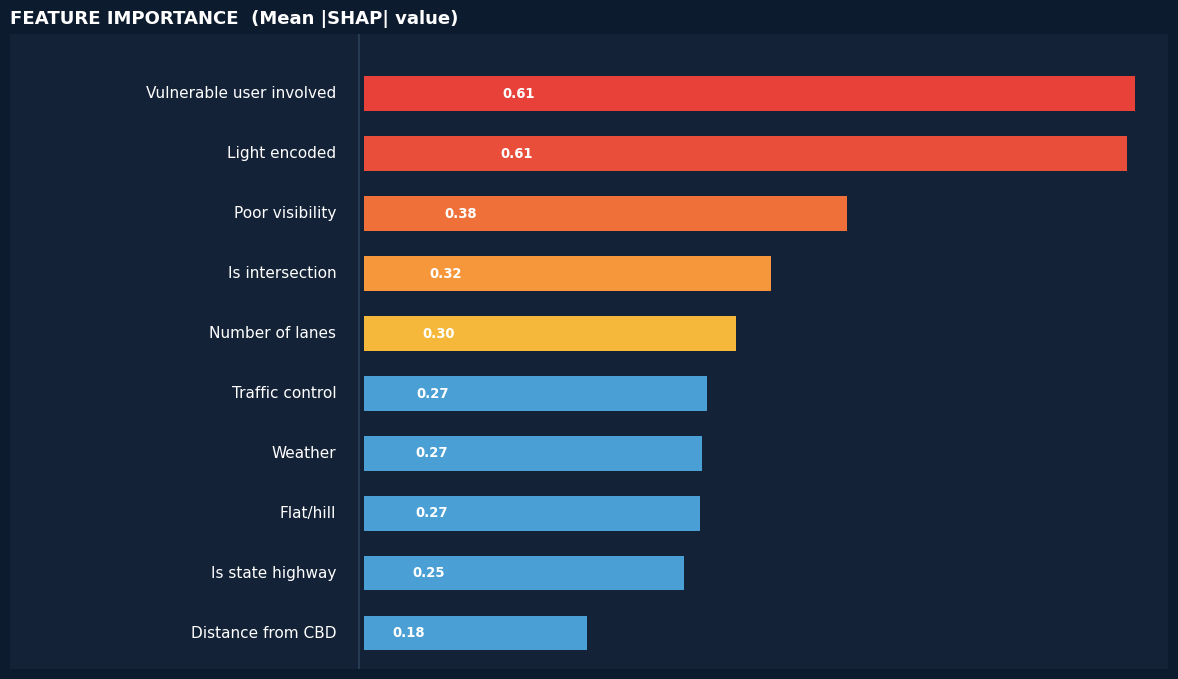

✅ shap_importance_bar.png saved


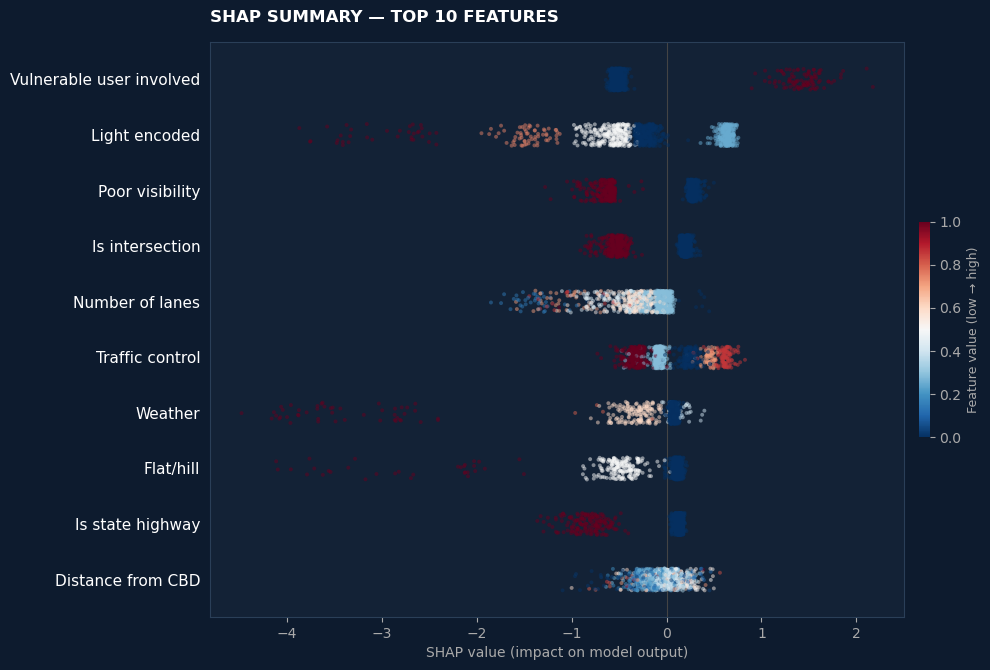

✅ shap_summary.png saved

📊 TOP 10 SHAP FEATURE IMPORTANCE
Rank  Feature                       Mean |SHAP|
------------------------------------------------
  1   Vulnerable user involved          0.6134
  2   Light encoded                     0.6075
  3   Poor visibility                   0.3842
  4   Is intersection                   0.3235
  5   Number of lanes                   0.2963
  6   Traffic control                   0.2728
  7   Weather                           0.2689
  8   Flat/hill                         0.2676
  9   Is state highway                  0.2546
  10  Distance from CBD                 0.1773


In [41]:
import shap, matplotlib.pyplot as plt, matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import numpy as np, os

os.makedirs("/lakehouse/default/Files/outputs", exist_ok=True)

# ── Compute SHAP values ───────────────────────────────────────────────────────
explainer   = shap.TreeExplainer(xgb_m)
X_sample    = X_test.sample(n=min(1000, len(X_test)), random_state=42)
shap_values = explainer.shap_values(X_sample)

# Mean |SHAP| per feature — importance score
shap_mean = np.abs(shap_values).mean(axis=0)
importance_df = (
    pd.DataFrame({'feature': X_sample.columns, 'shap_mean': shap_mean})
    .sort_values('shap_mean', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

# Clean display names — matches image labels
label_map = {
    'vulnerable_user_involved': 'Vulnerable user involved',
    'light_encoded':            'Light encoded',
    'poor_visibility':          'Poor visibility',
    'is_intersection':          'Is intersection',
    'NumberOfLanes':            'Number of lanes',
    'trafficControl_encoded':   'Traffic control',
    'weatherA_encoded':         'Weather',
    'flatHill_clean_encoded':   'Flat/hill',
    'is_state_highway':         'Is state highway',
    'distance_from_cbd_km':     'Distance from CBD',
    'roadLane_clean_encoded':   'Road lane',
    'roadSurface_encoded':      'Road surface',
    'urban_clean_encoded':      'Urban type',
    'speedLimit':               'Speed limit',
    'is_cbd_area':              'Is CBD area',
    'has_pedestrian':           'Has pedestrian',
    'has_bicycle':              'Has bicycle',
    'has_motorcycle':           'Has motorcycle',
    'roadCharacter_encoded':    'Road character',
    'complex_traffic_control':  'Complex traffic ctrl',
}
importance_df['label'] = importance_df['feature'].map(
    lambda f: label_map.get(f, f.replace('_',' ').replace(' encoded','').title())
)

# ── Colour gradient: red → orange → yellow → blue (top→bottom) ───────────────
bar_colors = [
    '#E8413A',   # 1 red
    '#E84E3A',   # 2 red-orange
    '#F0703A',   # 3 orange
    '#F5973A',   # 4 orange-yellow
    '#F5B83A',   # 5 yellow-orange
    '#4A9FD4',   # 6 blue
    '#4A9FD4',   # 7 blue
    '#4A9FD4',   # 8 blue
    '#4A9FD4',   # 9 blue
    '#4A9FD4',   # 10 blue
]

# ════════════════════════════════════════════════════════════════════════════
# PLOT 1: Feature Importance Bar Chart — dark navy style matching design image
# ════════════════════════════════════════════════════════════════════════════
BG     = '#0D1B2E'   # dark navy background
PANEL  = '#132236'   # slightly lighter panel

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(BG)
ax.set_facecolor(PANEL)

n       = len(importance_df)
max_val = importance_df['shap_mean'].max()

# X layout in pure data units — avoids blended transform issues
# 0.0 – 3.0  : label zone
# 3.15 – 10.0: bar zone
LABEL_END = 3.0
BAR_START = 3.15
BAR_END   = 10.0
bar_range = BAR_END - BAR_START

for i, (_, row) in enumerate(importance_df.iterrows()):
    yp    = n - 1 - i           # top = rank 1
    val   = row['shap_mean']
    color = bar_colors[i] if i < len(bar_colors) else '#4A9FD4'
    frac  = val / max_val
    bar_w = frac * bar_range

    # Bar — pure data coords
    ax.barh(yp, bar_w, left=BAR_START, height=0.58,
            color=color, zorder=3)

    # Feature label — right-aligned in label zone, explicit white color
    ax.text(LABEL_END - 0.1, yp, row['label'],
            va='center', ha='right',
            color='#FFFFFF',
            fontsize=11, fontweight='normal')

    # Value badge — inside bar, pure data coords
    ax.text(BAR_START + bar_w * 0.20, yp, f"{val:.2f}",
            va='center', ha='center',
            color='#FFFFFF',
            fontsize=9.5, fontweight='bold')

# Separator line
ax.axvline(BAR_START - 0.05, color='#2A3F58', linewidth=1.2, zorder=2)

# Title — data coords
ax.text(0.0, n + 0.1,
        'FEATURE IMPORTANCE  (Mean |SHAP| value)',
        color='#FFFFFF', fontsize=13, fontweight='bold', va='bottom')

for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks([]); ax.set_yticks([])
ax.set_xlim(0.0, BAR_END + 0.3)
ax.set_ylim(-0.6, n)
ax.tick_params(left=False, bottom=False)

plt.tight_layout(pad=1.5)
plt.savefig("/lakehouse/default/Files/outputs/shap_importance_bar.png",
            dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()
print("✅ shap_importance_bar.png saved")

# ════════════════════════════════════════════════════════════════════════════
# PLOT 2: SHAP Beeswarm Summary — dark navy style
# ════════════════════════════════════════════════════════════════════════════
# Get top 10 features in order of importance
top_features = importance_df['feature'].tolist()
top_idx      = [list(X_sample.columns).index(f) for f in top_features
                if f in X_sample.columns]
top_labels   = importance_df['label'].tolist()

shap_top     = shap_values[:, top_idx]
X_top        = X_sample.iloc[:, top_idx]

fig2, ax2 = plt.subplots(figsize=(10, 7))
fig2.patch.set_facecolor(BG)
ax2.set_facecolor(PANEL)

# Plot each feature as a strip of dots
for i, feat_idx in enumerate(range(len(top_features))):
    yp       = len(top_features) - 1 - feat_idx   # top = rank 1
    sv       = shap_top[:, feat_idx]
    feat_val = X_top.iloc[:, feat_idx].values
    feat_val_norm = (feat_val - feat_val.min()) / (feat_val.max() - feat_val.min() + 1e-9)

    # Jitter y
    jitter = np.random.RandomState(feat_idx).uniform(-0.2, 0.2, len(sv))

    # Colour: blue (low feature value) → red (high feature value)
    colors_dot = plt.cm.RdBu_r(feat_val_norm)

    ax2.scatter(sv, yp + jitter, c=colors_dot, alpha=0.5,
                s=8, zorder=3, linewidths=0)

# Feature labels — explicit #FFFFFF, no TEXT variable dependency
ax2.set_yticks(range(len(top_features)))
ax2.set_yticklabels(top_labels[::-1], color='#FFFFFF', fontsize=11)
ax2.tick_params(axis='y', left=False, labelcolor='#FFFFFF')

# X axis
ax2.axvline(0, color='#444', linewidth=0.8, zorder=2)
ax2.set_xlabel("SHAP value (impact on model output)", color='#AAAAAA', fontsize=10)
ax2.tick_params(axis='x', colors='#AAAAAA')

# Colourbar
sm = plt.cm.ScalarMappable(cmap='RdBu_r', norm=plt.Normalize(0, 1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax2, fraction=0.015, pad=0.02)
cbar.set_label('Feature value (low → high)', color='#AAAAAA', fontsize=9)
cbar.ax.yaxis.set_tick_params(color='#AAAAAA')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#AAAAAA')
cbar.outline.set_visible(False)

# Title — explicit #FFFFFF
ax2.text(0, 1.03, 'SHAP SUMMARY — TOP 10 FEATURES',
         transform=ax2.transAxes, color='#FFFFFF',
         fontsize=12, fontweight='bold', va='bottom')

for spine in ax2.spines.values():
    spine.set_color('#2A3F58')
ax2.set_facecolor(PANEL)
fig2.patch.set_facecolor(BG)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("/lakehouse/default/Files/outputs/shap_summary.png",
            dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()
print("✅ shap_summary.png saved")

# ── Print importance table ────────────────────────────────────────────────────
print("\n📊 TOP 10 SHAP FEATURE IMPORTANCE")
print("=" * 48)
print(f"{'Rank':<6}{'Feature':<30}{'Mean |SHAP|':>10}")
print("-" * 48)
for i, (_, r) in enumerate(importance_df.iterrows(), 1):
    print(f"  {i:<4}{r['label']:<30}{r['shap_mean']:>10.4f}")
print("=" * 48)

In [42]:
preds=X_test.copy()
preds['actual_severe']=y_test.values; 
preds['predicted_severe_xgb']=y_pred_xgb
preds['prediction_probability_xgb']=y_proba_xgb; 
preds['high_risk_flag']=(y_proba_xgb>=0.70).astype(int)
# Join coordinates back using index — X_test retains df_gold row index
preds['X'] = df_gold.loc[X_test.index, 'X'].values   # longitude
preds['Y'] = df_gold.loc[X_test.index, 'Y'].values   # latitude

# Optionally add road name for tooltip
if 'crashLocation1' in df_gold.columns:
    preds['crashLocation1'] = df_gold.loc[X_test.index, 'crashLocation1'].values
if 'crashSeverity_clean' in df_gold.columns:
    preds['crashSeverity_clean'] = df_gold.loc[X_test.index, 'crashSeverity_clean'].values
if 'crashYear_int' in df_gold.columns:
    preds['crashYear_int'] = df_gold.loc[X_test.index, 'crashYear_int'].values

# Verify coordinates joined correctly
print(f"Predictions with coordinates: {preds[['X','Y']].notna().all(axis=1).sum():,}")
print(f"X range: {preds['X'].min():.4f} – {preds['X'].max():.4f}")
print(f"Y range: {preds['Y'].min():.4f} – {preds['Y'].max():.4f}")
print(f"High risk crashes: {preds['high_risk_flag'].sum():,}")
spark.createDataFrame(preds).write.format("delta").mode("overwrite").saveAsTable("gold_ml_predictions")

spark.createDataFrame(pd.DataFrame([
    {'Model':'Logistic Regression','ROC-AUC':round(roc_lr,4),'Recall':round(r_lr,4),'Precision':round(p_lr,4),'F1':round(f1_lr,4),'Improvement_pct':0.0},
    {'Model':'Random Forest',      'ROC-AUC':round(roc_rf,4),'Recall':round(r_rf,4),'Precision':round(p_rf,4),'F1':round(f1_rf,4),'Improvement_pct':round((roc_rf-roc_lr)/roc_lr*100,2)},
    {'Model':'XGBoost',            'ROC-AUC':round(roc_xgb,4),'Recall':round(r_xgb,4),'Precision':round(p_xgb,4),'F1':round(f1_xgb,4),'Improvement_pct':round((roc_xgb-roc_lr)/roc_lr*100,2)},
])).write.format("delta").mode("overwrite").saveAsTable("gold_ml_model_comparison")
print("Saved: gold_ml_predictions, gold_ml_model_comparison")

StatementMeta(, 9eaae936-6225-4958-af48-2118803d9200, 59, Finished, Available, Finished, False)

Predictions with coordinates: 22,332
X range: 174.4500 – 175.2203
Y range: -37.1496 – -36.6505
High risk crashes: 1,281
Saved: gold_ml_predictions, gold_ml_model_comparison


In [43]:
# # Add Lat, Long to the table
# preds = spark.table("gold_ml_predictions").toPandas()

# # gold_crashes_features has all rows including test set
# df_all = spark.table("gold_crashes_features").toPandas()

# # X_test was 20% stratified split — we can identify test rows by
# # checking which rows are NOT in X_train (harder without saving index)
# # Easier: just re-add coordinates by re-running the split with same seed

# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import LabelEncoder
# import pandas as pd

# feature_cols = [
#     'speedLimit','NumberOfLanes','distance_from_cbd_km','is_cbd_area',
#     'has_pedestrian','has_bicycle','has_motorcycle',
#     'vulnerable_user_involved','is_state_highway',
#     'poor_visibility','is_intersection','complex_traffic_control',
# ]
# cat_features = ['weatherA','light','roadSurface','trafficControl',
#                 'flatHill_clean','roadLane_clean','urban_clean','roadCharacter']
# for col in cat_features:
#     if col in df_all.columns:
#         df_all[f'{col}_encoded'] = LabelEncoder().fit_transform(df_all[col].fillna('Unknown'))

# all_features = [f for f in feature_cols if f in df_all.columns] + \
#                [f'{c}_encoded' for c in cat_features if c in df_all.columns]
# X = df_all[all_features].fillna(0)
# y = df_all['severe_crash']

# # Same seed = same split = same test rows
# _, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# # Now X_test.index matches the test rows in df_all
# preds['X'] = df_all.loc[X_test.index, 'X'].values
# preds['Y'] = df_all.loc[X_test.index, 'Y'].values
# if 'crashLocation1' in df_all.columns:
#     preds['crashLocation1'] = df_all.loc[X_test.index, 'crashLocation1'].values
# if 'crashSeverity_clean' in df_all.columns:
#     preds['crashSeverity_clean'] = df_all.loc[X_test.index, 'crashSeverity_clean'].values

# print(f"Coordinates added: {preds[['X','Y']].notna().sum().min():,} rows")
# spark.createDataFrame(preds).write.format("delta").mode("overwrite") \
#      .option("overwriteSchema", "True").saveAsTable("gold_ml_predictions")
# print("gold_ml_predictions updated with X, Y")

StatementMeta(, 9eaae936-6225-4958-af48-2118803d9200, 60, Finished, Available, Finished, False)

In [44]:
# ── Correct coordinate fix — filter by Auckland bounds explicitly ─────────────
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load with explicit sort to guarantee consistent row order
df_all = spark.table("gold_crashes_features") \
              .orderBy("X", "Y") \
              .toPandas()

# Auckland bounding box — filter BEFORE split to match original run
AUCKLAND_LON = (174.40, 175.30)
AUCKLAND_LAT = (-37.20, -36.60)

df_all = df_all[
    df_all['X'].between(*AUCKLAND_LON) &
    df_all['Y'].between(*AUCKLAND_LAT) &
    df_all['X'].notna() & df_all['Y'].notna()
].reset_index(drop=True)

print(f"Auckland crashes after bounds filter: {len(df_all):,}")
print(f"X: {df_all['X'].min():.4f} – {df_all['X'].max():.4f}")
print(f"Y: {df_all['Y'].min():.4f} – {df_all['Y'].max():.4f}")

# Rebuild features — same as Day 5
feature_cols = [
    'speedLimit','NumberOfLanes','distance_from_cbd_km','is_cbd_area',
    'has_pedestrian','has_bicycle','has_motorcycle',
    'vulnerable_user_involved','is_state_highway',
    'poor_visibility','is_intersection','complex_traffic_control',
]
cat_features = [
    'weatherA','light','roadSurface','trafficControl',
    'flatHill_clean','roadLane_clean','urban_clean','roadCharacter'
]
for col in cat_features:
    if col in df_all.columns:
        df_all[f'{col}_encoded'] = LabelEncoder().fit_transform(
            df_all[col].fillna('Unknown'))

all_features = ([f for f in feature_cols if f in df_all.columns] +
                [f'{c}_encoded' for c in cat_features if c in df_all.columns])
X = df_all[all_features].fillna(0)
y = df_all['severe_crash']

# Same split parameters as Day 5
_, X_test, _, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Load existing predictions and assign coordinates by position
preds = spark.table("gold_ml_predictions").toPandas()
print(f"\nPredictions rows : {len(preds):,}")
print(f"X_test rows      : {len(X_test):,}")

# Safety check — must match
assert len(preds) == len(X_test), \
    f"Row count mismatch: preds={len(preds)} vs X_test={len(X_test)}"

# Assign coordinates using index alignment
preds['X'] = df_all.loc[X_test.index, 'X'].values
preds['Y'] = df_all.loc[X_test.index, 'Y'].values
preds['crashLocation1']    = df_all.loc[X_test.index, 'crashLocation1'].values
preds['crashSeverity_clean'] = df_all.loc[X_test.index, 'crashSeverity_clean'].values
preds['crashYear_int']     = df_all.loc[X_test.index, 'crashYear_int'].values

# Verify coordinates are within Auckland
out_of_bounds = preds[
    ~preds['X'].between(*AUCKLAND_LON) |
    ~preds['Y'].between(*AUCKLAND_LAT)
]
print(f"\nOut of bounds points: {len(out_of_bounds)}")
print(f"X range: {preds['X'].min():.4f} – {preds['X'].max():.4f}")
print(f"Y range: {preds['Y'].min():.4f} – {preds['Y'].max():.4f}")
print(f"High risk crashes: {preds['high_risk_flag'].sum():,}")

# Save back
spark.createDataFrame(preds).write.format("delta").mode("overwrite") \
     .saveAsTable("gold_ml_predictions_coordinates")
print("\ngold_ml_predictions updated — Auckland bounds enforced")

StatementMeta(, 9eaae936-6225-4958-af48-2118803d9200, 61, Finished, Available, Finished, False)

Auckland crashes after bounds filter: 111,657
X: 174.4500 – 175.2459
Y: -37.1500 – -36.6500

Predictions rows : 22,332
X_test rows      : 22,332

Out of bounds points: 0
X range: 174.4502 – 175.2417
Y range: -37.1500 – -36.6502
High risk crashes: 1,281

gold_ml_predictions updated — Auckland bounds enforced
